In [ ]:
!apt-get update -qq
!apt-get install -y r-base r-base-dev

Reading package lists... DoneBuilding dependency tree... DoneReading state information... Doner-base is already the newest version.r-base-dev is already the newest version.

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages('remotes')
remotes::install_github('rstudio/reticulate')

* DONE (remotes)Skipping install of 'reticulate' from a github remote, the SHA1 (xxxxxxxx) has not changed since last install.  Use `force = TRUE` to force installation

# R Image Classification - Cars vs Planes
## CNN using Keras in R

In [ ]:
%%R
system('apt-get update && apt-get install -y libfftw3-dev libtiff-dev libxml2-dev')
install.packages('BiocManager')
BiocManager::install('EBImage')
install.packages(c('keras3', 'tensorflow', 'abind'))
library(keras3)
library(tensorflow)
library(EBImage)
library(abind)

* DONE (EBImage)* DONE (keras3)* DONE (abind)TensorFlow v2.21.0 (~/.cache/uv/.../site-packages/keras)Python v3.12

## Read Images

In [ ]:
%%R
setwd('/content')
list.files()

 [1] "c1.jpg" "c2.jpg" "c3.jpg" "c4.jpg" "c5.jpg" "c6.jpg" "p1.jpg" "p2.jpg" [9] "p3.jpg" "p4.jpg" "p5.jpg" "p6.jpg"

In [ ]:
%%R
pics <- c('p1.jpg', 'p2.jpg', 'p3.jpg', 'p4.jpg', 'p5.jpg', 'p6.jpg',
          'c1.jpg', 'c2.jpg', 'c3.jpg', 'c4.jpg', 'c5.jpg', 'c6.jpg')

mypic <- list()

for (i in 1:12) {
  img <- readImage(pics[i])
  img <- resize(img, 28, 28)
  mypic[[i]] <- img
  print(paste('Loaded:', pics[i], 'Shape:', paste(dim(img), collapse=' x ')))
}

[1] "Loaded: p1.jpg Shape: 28 x 28 x 3"[1] "Loaded: p2.jpg Shape: 28 x 28 x 3"[1] "Loaded: p3.jpg Shape: 28 x 28 x 3"[1] "Loaded: p4.jpg Shape: 28 x 28 x 3"[1] "Loaded: p5.jpg Shape: 28 x 28 x 3"[1] "Loaded: p6.jpg Shape: 28 x 28 x 3"[1] "Loaded: c1.jpg Shape: 28 x 28 x 3"[1] "Loaded: c2.jpg Shape: 28 x 28 x 3"[1] "Loaded: c3.jpg Shape: 28 x 28 x 3"[1] "Loaded: c4.jpg Shape: 28 x 28 x 3"[1] "Loaded: c5.jpg Shape: 28 x 28 x 3"[1] "Loaded: c6.jpg Shape: 28 x 28 x 3"

## Explore Images

Image   colorMode    : Color   storage.mode : double   dim          : 28 28 3   frames.total : 3   frames.render: 1 imageData(object)[1:5,1:6,1]          [,1]      [,2]      [,3]      [,4]      [,5]      [,6][1,] 0.1409976 0.1378614 0.1282375 0.1451681 0.1390744 0.1456645[2,] 0.1470588 0.1501376 0.1422969 0.1351366 0.1369160 0.1378151[3,] 0.1450980 0.1358056 0.1437200 0.1498249 0.1407688 0.1377063[4,] 0.1365721 0.1379727 0.1372549 0.1372549 0.1362045 0.1423407[5,] 0.1446103 0.1378927 0.1313851 0.1483281 0.1378739 0.1453644   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.  0.0140  0.1483  0.3639  0.3772  0.6769  0.9995 

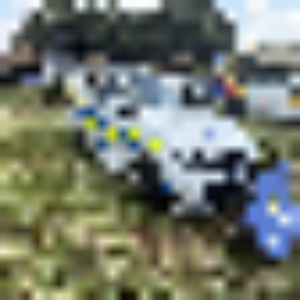

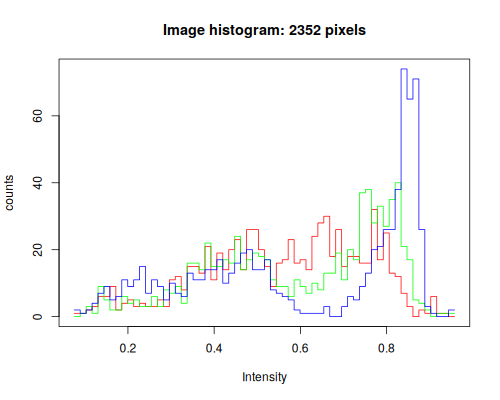

Formal class 'Image' [package "EBImage"] with 2 slots  ..@ .Data    : num [1:28, 1:28, 1:3] 0.141 0.147 0.145 0.137 0.145 ...  ..@ colormode: int 2  ..$ dim: int [1:3] 28 28 3

In [ ]:
%%R
print(mypic[[1]])
display(mypic[[8]])
summary(mypic[[1]])
hist(mypic[[2]])
str(mypic)

## Resize Images

In [ ]:
%%R
for (i in 1:12) {mypic[[i]] <- resize(mypic[[i]], 28, 28)}

## Reshape to Array Format

In [ ]:
%%R
for (i in 1:12) {mypic[[i]] <- array_reshape(mypic[[i]], c(28, 28, 3))}

## Prepare Training Data

In [ ]:
%%R
trainx <- NULL
for (i in 1:10) {trainx <- abind(trainx, mypic[[i]], along=1)}

trainx <- array_reshape(trainx, c(10, 28, 28, 3))
trainx <- trainx / 255

str(trainx)

testx <- array(NA, dim = c(2, 28, 28, 3))
testx[1,,,] <- mypic[[11]]
testx[2,,,] <- mypic[[12]]
testx <- testx / 255

trainy <- c(0, 0, 0, 0, 0, 1, 1, 1, 1, 1)
testy <- c(0, 1)

 num [1:10, 1:28, 1:28, 1:3] 0.141 0.126 0.204 0.09 0.129 ...

## One-Hot Encoding

In [ ]:
%%R
trainLabels <- to_categorical(trainy)
testLabels <- to_categorical(testy)

## Build CNN Model

In [ ]:
%%R
model <- keras_model_sequential()

model %>%
  layer_conv_2d(filters = 32, kernel_size = c(3, 3), activation = 'relu', input_shape = c(28, 28, 3)) %>%
  layer_max_pooling_2d(pool_size = c(2, 2)) %>%
  layer_conv_2d(filters = 64, kernel_size = c(3, 3), activation = 'relu') %>%
  layer_max_pooling_2d(pool_size = c(2, 2)) %>%
  layer_flatten() %>%
  layer_dense(units = 128, activation = 'relu') %>%
  layer_dropout(rate = 0.5) %>%
  layer_dense(units = 2, activation = 'softmax')

summary(model)

Model: "sequential"+-----------------------------------+----------------------------+---------------+| Layer (type)                      | Output Shape               |     Param #   |+=====================================================================================+| conv2d (Conv2D)                    | (None, 26, 26, 32)         |           896 |+-----------------------------------+----------------------------+---------------+| max_pooling2d (MaxPooling2D)       | (None, 13, 13, 32)         |             0 |+-----------------------------------+----------------------------+---------------+| conv2d_1 (Conv2D)                  | (None, 11, 11, 64)         |        18,496 |+-----------------------------------+----------------------------+---------------+| max_pooling2d_1 (MaxPooling2D)     | (None, 5, 5, 64)           |             0 |+-----------------------------------+----------------------------+---------------+| flatten (Flatten)                  | (None, 1600)               |   

## Compile Model

In [ ]:
%%R
model %>% compile(
  loss = 'categorical_crossentropy',
  optimizer = optimizer_adam(),
  metrics = c('accuracy')
)

## Train Model

In [ ]:
%%R
history <- model %>%
  fit(trainx,
      trainLabels,
      epochs = 30,
      batch_size = 2,
      validation_split = 0.2,
      verbose = 1)

## Plot Training History

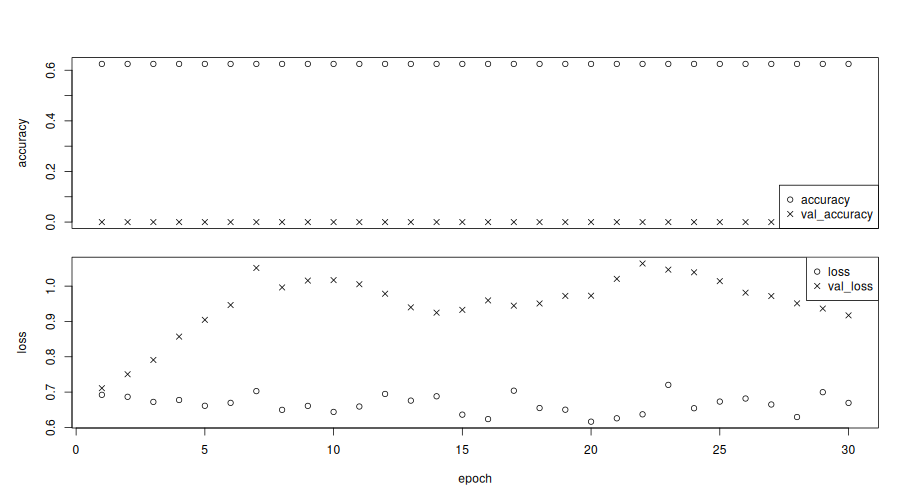

In [ ]:
%%R
plot(history)

## Evaluate and Predict - Train Data

In [ ]:
%%R
eval_train <- model %>% evaluate(trainx, trainLabels)
print(eval_train)

pred_train <- model %>% predict(trainx)
pred_train_classes <- apply(pred_train, 1, which.max) - 1

table(Predicted = pred_train_classes, Actual = trainy)

pred_train_prob <- as.data.frame(pred_train)
colnames(pred_train_prob) <- c('Plane', 'Car')
cbind(pred_train_prob, Predicted = pred_train_classes, Actual = trainy)

$accuracy[1] 0.5$loss[1] 0.7133959         ActualPredicted 0 1        0 5 5      Plane       Car Predicted Actual1  0.6005366 0.3994634         0      02  0.6023762 0.3976238         0      03  0.6031589 0.3968412         0      04  0.6001834 0.3998166         0      05  0.6006778 0.3993222         0      06  0.6010238 0.3989762         0      17  0.6009386 0.3990614         0      18  0.6012619 0.3987381         0      19  0.5998186 0.4001813         0      110 0.6009155 0.3990846         0      1

## Evaluate and Predict - Test Data

In [ ]:
%%R
eval_test <- model %>% evaluate(testx, testLabels)
print(eval_test)

pred_test <- model %>% predict(testx)
pred_test_classes <- apply(pred_test, 1, which.max) - 1

table(Predicted = pred_test_classes, Actual = testy)

pred_test_prob <- as.data.frame(pred_test)
colnames(pred_test_prob) <- c('Plane', 'Car')
cbind(pred_test_prob, Predicted = pred_test_classes, Actual = testy)

$accuracy[1] 0.5$loss[1] 0.7136477         ActualPredicted 0 1        0 1 1      Plane       Car Predicted Actual1 0.6010586 0.3989415         0      02 0.6007760 0.3992241         0      1

## Observations

- The CNN was trained on a **very small dataset** (10 training images: 5 planes + 5 cars, 2 test images: 1 plane + 1 car), which is far below what a CNN typically needs to generalize.
- Training accuracy plateaued at **62.5%** and both train and test accuracy after evaluation settled at **50%** — the model largely predicts the majority/first class rather than learning discriminative features.
- This is an expected outcome given the dataset size, and matches the behavior demonstrated in the reference tutorial: the exercise's purpose is to demonstrate the **end-to-end CNN workflow in R** (image loading with `EBImage`, preprocessing, array reshaping, one-hot encoding, model building with `keras3`, training, and evaluation), not to achieve high classification accuracy.
- Increasing the dataset size (dozens to hundreds of images per class) and using data augmentation would be the natural next step to improve real classification performance.